In [ ]:
from google.colab import files
files.upload()

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d venky73/spam-mails-dataset

Dataset URL: https://www.kaggle.com/datasets/venky73/spam-mails-dataset
License(s): CC0-1.0
100% 1.86M/1.86M [00:00<00:00, 145MB/s]



In [5]:
!unzip spam-mails-dataset.zip

Archive:  spam-mails-dataset.zip
  inflating: spam_ham_dataset.csv    


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , top_k_accuracy_score , confusion_matrix
from sklearn.naive_bayes import MultinomialNB , BernoulliNB , ComplementNB
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
#from scipy.spatial import cdist
from scipy.sparse import coo_matrix


In [26]:
df = pd.read_csv('spam_ham_dataset.csv')
#df.head()
df.describe()


,Unnamed: 0,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


In [10]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [16]:
df.isnull().sum()

,0
Unnamed: 0,0
label,0
text,0
label_num,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [22]:
df = df.drop("label" , axis = 1, errors='ignore')
df = df.drop("Unnamed: 0" , axis = 1, errors='ignore')

In [23]:
df.head(10)

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0
5,Subject: ehronline web address change\r\nthis ...,0
6,Subject: spring savings certificate - take 30 ...,0
7,Subject: looking for medication ? we ` re the ...,1
8,Subject: noms / actual flow for 2 / 26\r\nwe a...,0
9,"Subject: nominations for oct . 21 - 23 , 2000\...",0


In [24]:
df['label_num'].value_counts()

,count
label_num,
0,3672
1,1499


Testing with no balancing . Use ComplementNB

In [27]:
X = df["text"]
y = df["label_num"]
print(X)
print(y)

0       Subject: enron methanol ; meter # : 988291\r\n...
1       Subject: hpl nom for january 9 , 2001\r\n( see...
2       Subject: neon retreat\r\nho ho ho , we ' re ar...
3       Subject: photoshop , windows , office . cheap ...
4       Subject: re : indian springs\r\nthis deal is t...
                              ...                        
5166    Subject: put the 10 on the ft\r\nthe transport...
5167    Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168    Subject: calpine daily gas nomination\r\n>\r\n...
5169    Subject: industrial worksheets for august 2000...
5170    Subject: important online banking alert\r\ndea...
Name: text, Length: 5171, dtype: object
0       0
1       0
2       0
3       1
4       0
       ..
5166    0
5167    0
5168    0
5169    0
5170    1
Name: label_num, Length: 5171, dtype: int64


In [28]:
vectorizer = TfidfVectorizer(stop_words='english' , max_features=10000)
# Tính TF , IDF , bỏ qua các từ nhiễu : is , are , to , .. Giữ lại 10000 từ có TF - IDF cao nhất

In [29]:
X_vec = vectorizer.fit_transform(X)

In [33]:
X_train , X_test , y_train , y_test = train_test_split(X_vec , y , test_size = 0.2 , random_state = 42)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4136, 10000)
(1035, 10000)
(4136,)
(1035,)


In [44]:
model_cnb = ComplementNB(alpha = 5.0)
model_cnb.fit(X_train , y_train)

ComplementNB(alpha=5.0)

In [45]:
accuracy_cnb = accuracy_score(y_test , model_cnb.predict(X_test))
print(f"ComplementNB Accuracy: {accuracy_cnb}")

ComplementNB Accuracy: 0.9681159420289855


### Multinomial Naive Bayes

In [46]:
model_mnb = MultinomialNB(alpha=1.0) # You can tune alpha
model_mnb.fit(X_train, y_train)
accuracy_mnb = accuracy_score(y_test, model_mnb.predict(X_test))
print(f"MultinomialNB Accuracy: {accuracy_mnb}")

MultinomialNB Accuracy: 0.966183574879227


### Bernoulli Naive Bayes

In [47]:
model_bnb = BernoulliNB(alpha=1.0) # You can tune alpha
model_bnb.fit(X_train, y_train)
accuracy_bnb = accuracy_score(y_test, model_bnb.predict(X_test))
print(f"BernoulliNB Accuracy: {accuracy_bnb}")

BernoulliNB Accuracy: 0.9178743961352657


### Comparison of Naive Bayes Models

/tmp/ipykernel_1694/1826814742.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=models_df, palette='viridis')


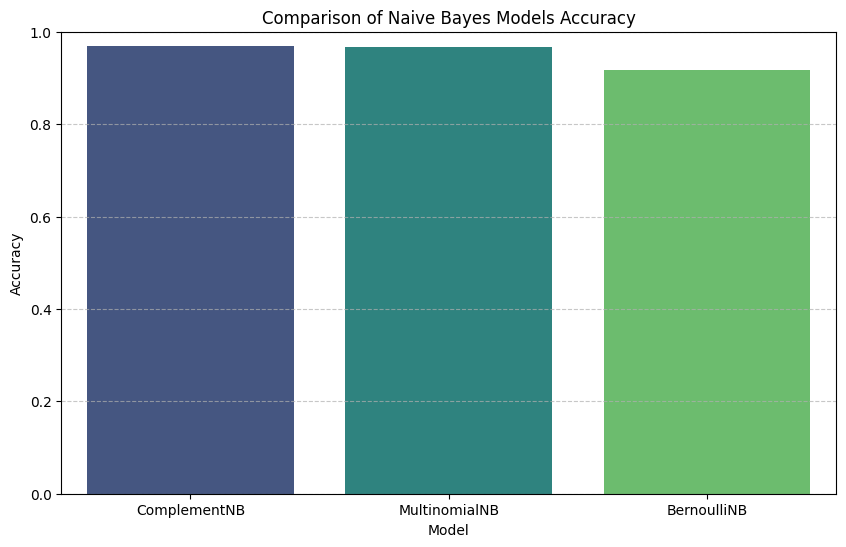

In [48]:
accuracies = {
    'ComplementNB': accuracy_cnb,
    'MultinomialNB': accuracy_mnb,
    'BernoulliNB': accuracy_bnb
}

models_df = pd.DataFrame(accuracies.items(), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=models_df, palette='viridis')
plt.title('Comparison of Naive Bayes Models Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()